# 🔬 06-二阶优化方法

> 目标：牛顿法为什么是「曲率自适应」、为什么深度学习用不起、拟牛顿 BFGS / L-BFGS 与 K-FAC 的思路。

## §1 牛顿法

对 $f$ 做二阶泰勒展开求极小：$f(w+\Delta) \approx f(w) + g^\top\Delta + \tfrac12 \Delta^\top H \Delta$

对 $\Delta$ 求导为零 → $\boxed{\Delta = -H^{-1} g}$，更新 $w \gets w - H^{-1}g$。

**与梯度下降的关系**：梯度下降是「以欧氏度量」的最速下降；牛顿法是「以 $H$ 为度量的内积空间」的最速下降 → 对病态条件数（椭圆等高线）天然自适应曲率，**一步到位（二次函数）**。

**代价**：$H$ 是 $n\times n$（$n$=参数量），存 $O(n^2)$、求逆 $O(n^3)$ → 7B 模型 $n^2=4.9\times10^{19}$，完全不可行。

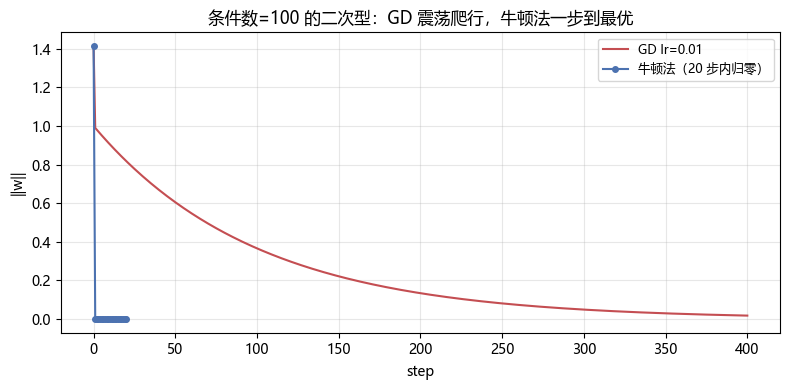

GD 400 步后 ||w||=0.018；牛顿法第 1 步即归零


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 实验 1：病态二次型上 GD vs 牛顿法 ----------
def quad_grad(w, H):
    return H @ w

H = np.diag([1.0, 100.0])   # 条件数 100：y 方向陡
w0 = np.array([1.0, 1.0])

def run_gd(steps=400, lr=0.01):
    w = w0.copy(); dists = [np.linalg.norm(w)]
    for _ in range(steps):
        w = w - lr * quad_grad(w, H)
        dists.append(np.linalg.norm(w))
    return np.array(dists)

def run_newton():
    w = w0.copy(); dists = [np.linalg.norm(w)]
    for _ in range(20):
        w = w - np.linalg.solve(H, quad_grad(w, H))   # H 恒定
        dists.append(np.linalg.norm(w))
    return np.array(dists)

fig, ax = plt.subplots(figsize=(8, 4.0))
ax.plot(run_gd(), label='GD lr=0.01', color='#C44E52', lw=1.5)
ax.plot(run_newton(), label='牛顿法（20 步内归零）', color='#4C72B0', lw=1.5, marker='o', ms=4)
ax.set_xlabel('step'); ax.set_ylabel('||w||')
ax.set_title('条件数=100 的二次型：GD 震荡爬行，牛顿法一步到最优', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('GD 400 步后 ||w||=%.3f；牛顿法第 1 步即归零' % run_gd()[-1])

## §2 为什么深度学习不用牛顿法

1. **存不下**：$H \in \mathbb{R}^{n\times n}$，$O(n^2)$ 内存（7B 模型不可行）
2. **算不起**：求逆 $O(n^3)$
3. **非凸**：$H$ 未必正定，$H^{-1}g$ 可能不是下降方向（需 damping）
4. **mini-batch 噪声**：Hessian 估计方差大

缓解：**拟牛顿**——用梯度差近似 $H^{-1}$。

## §3 BFGS 与 L-BFGS

- **BFGS**：维护 $B_k \approx H_k$，用两次迭代的梯度差 $s_k, y_k$ 做秩 2 更新（曲率条件 $s_k^\top y_k > 0$），无需二阶导
- **L-BFGS**：不存 $B_k$，只存最近 $m$ 步的 $(s_k, y_k)$，用两循环递归近似 $H^{-1}$ → 内存 $O(mn)$
- 适用：中小规模凸问题（逻辑回归、SVM 对偶）效果好；深度网络仍不用（非凸 + 大数据）

## §4 K-FAC / Shampoo 一句话直觉

- **K-FAC**：把 Fisher 矩阵按层块对角化，每块近似为激活与梯度的 Kronecker 积 $A \otimes G$，求逆用 $A^{-1}\otimes G^{-1}$（小矩阵求逆）→ 二阶信息近似，仍是 $O(n)$ 内存
- **Shampoo**：每层用 Kronecker 因子近似 AdaGrad 累积矩阵

## §5 面试追问与自测

- 牛顿法更新公式：$w \gets w - H^{-1}g$；为什么二次函数一步到位
- 条件数如何影响 GD / 牛顿法的步数（本文实验）
- BFGS 的曲率条件 $s^\top y > 0$ 含义
- K-FAC 的「块对角 + Kronecker」为什么省内存

> 💡 下节预告：FP16/BF16 混合精度与 Adam 内存分析（07 篇）。